Agente de monedas Ocultas

In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt

np.random.seed(42)

Entorno: tablero de 5x5, el agente cava en cualquier hueco para encontrar la moneda, la mejor casilla es la que tiene mayor probabilidad de tener la moneda

In [17]:
tamano = 5
numeroCasillas = tamano*tamano

probabilida_real  = np.random.uniform(0,0.5,numeroCasillas)

mejorCasilla = np.argmax(probabilida_real)
print("Tablero")
print(f"Dimensiones: {tamano}x{tamano} = {numeroCasillas} casillas")

for i in range(tamano):
    fila = probabilida_real[i*tamano:(i+1)*tamano]
    print(f"  Fila {i}: {[f'{p:.2f}' for p in fila]}")
print(f"\nMejor casilla: fila {mejorCasilla//tamano}, columna {mejorCasilla%tamano} (probabilidad = {probabilida_real[mejorCasilla]:.3f})")

Tablero
Dimensiones: 5x5 = 25 casillas
  Fila 0: ['0.01', '0.19', '0.17', '0.05', '0.49']
  Fila 1: ['0.38', '0.33', '0.45', '0.46', '0.49']
  Fila 2: ['0.45', '0.28', '0.15', '0.29', '0.36']
  Fila 3: ['0.20', '0.04', '0.45', '0.19', '0.36']
  Fila 4: ['0.50', '0.42', '0.41', '0.09', '0.01']

Mejor casilla: fila 4, columna 0 (probabilidad = 0.499)


Algoritmo del Gradiente

In [18]:
def softmax(x):
    return np.exp(x) / sum(np.exp(x))

In [ ]:
partidas = 500
turnos = 200
alphas_grad = [0.1,0.4]  # diferentes tasas de aprendizaje

nombres_grad = [f'Gradiente (α={a})' for a in alphas_grad]
recompensas_grad = np.zeros((len(nombres_grad), turnos))
optimas_grad = np.zeros((len(nombres_grad), turnos))

for partida in range(partidas):
    for i, alfa in enumerate(alphas_grad):
        H = np.zeros(numeroCasillas) # probabilida de 1/25
        recompensas_historial = []  # guardamos todas las recompensas para calcular promedio
        for turno in range(turnos):
            probabilidades = softmax(H)
            # Las acciones con mayor preferencia tienen mayor probabilidad de ser elegidas
            casilla = np.random.choice(numeroCasillas, p=probabilidades)
            if(np.random.uniform() < probabilida_real[casilla]):
                recompensa = 1
            else:
                recompensa = 0
            recompensas_historial.append(recompensa)
            recompensa_promedio = np.mean(recompensas_historial)
            for j in range(numeroCasillas):
                if j == casilla:
                    # Accion elegida: aumentar su preferencia
                    H[j] += alfa * (recompensa - recompensa_promedio) * (1 - probabilidades[j])
                else:
                    # Acciones no elegidas: disminuir su preferencia
                    H[j] -= alfa * (recompensa - recompensa_promedio) * probabilidades[j]

            recompensas_grad[i][turno] += recompensa
            optimas_grad[i][turno] += (1 if casilla == mejorCasilla else 0)

recompensas_grad /= partidas
optimas_grad /= partidas

print(recompensa_promedio)
print(optimas_grad)

0.355
[[0.04  0.03  0.032 0.026 0.044 0.052 0.038 0.036 0.028 0.032 0.032 0.054
  0.042 0.028 0.034 0.046 0.04  0.03  0.04  0.04  0.046 0.05  0.046 0.042
  0.046 0.036 0.056 0.044 0.032 0.042 0.038 0.026 0.05  0.048 0.052 0.054
  0.046 0.032 0.034 0.056 0.038 0.054 0.042 0.034 0.04  0.034 0.038 0.038
  0.036 0.048 0.024 0.038 0.04  0.038 0.036 0.036 0.03  0.056 0.044 0.04
  0.038 0.038 0.046 0.046 0.042 0.04  0.038 0.056 0.034 0.038 0.036 0.048
  0.038 0.042 0.052 0.048 0.054 0.05  0.054 0.046 0.044 0.042 0.052 0.034
  0.042 0.03  0.044 0.038 0.038 0.032 0.028 0.048 0.028 0.042 0.05  0.038
  0.042 0.048 0.026 0.036 0.04  0.044 0.026 0.04  0.046 0.038 0.056 0.05
  0.036 0.026 0.042 0.052 0.038 0.034 0.026 0.042 0.034 0.046 0.054 0.042
  0.042 0.05  0.032 0.046 0.05  0.038 0.044 0.042 0.054 0.04  0.044 0.064
  0.048 0.046 0.052 0.07  0.044 0.056 0.048 0.024 0.028 0.042 0.036 0.048
  0.048 0.036 0.044 0.046 0.06  0.038 0.05  0.032 0.032 0.048 0.042 0.026
  0.054 0.044 0.034 0.04  0.048 0.

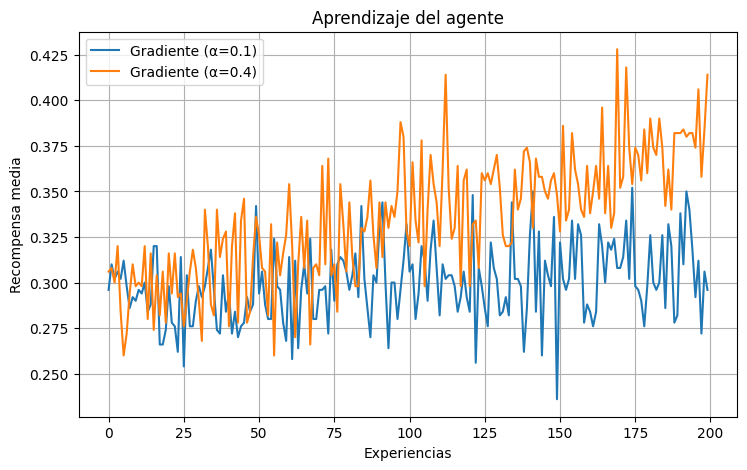

In [33]:
plt.figure(figsize=(8.5, 5))
for i, nombre in enumerate(nombres_grad):
    plt.plot(recompensas_grad[i], label=nombre)
plt.legend()
plt.grid(True)
plt.xlabel('Experiencias')
plt.ylabel('Recompensa media')
plt.title('Aprendizaje del agente')
plt.show()

In [ ]:
ventana = 50
promedios_finales = [np.mean(recompensas_grad[i][-ventana:]) for i in range(len(alphas_grad))]
mejor_indice = int(np.argmax(promedios_finales))
mejor_alpha = alphas_grad[mejor_indice]

mejor_alpha

def entrenar_agente_gradiente(alfa, turnos_entrenamiento=3000):
    H = np.zeros(numeroCasillas)
    historial_recompensas = []

    for turno in range(turnos_entrenamiento):
        probabilidades = softmax(H)
        casilla = np.random.choice(numeroCasillas, p=probabilidades)
        recompensa = 1 if np.random.uniform() < probabilida_real[casilla] else 0

        historial_recompensas.append(recompensa)
        recompensa_promedio = np.mean(historial_recompensas)
        ventaja = recompensa - recompensa_promedio

        for j in range(numeroCasillas):
            if j == casilla:
                H[j] += alfa * ventaja * (1 - probabilidades[j])
            else:
                H[j] -= alfa * ventaja * probabilidades[j]

    return H


In [35]:
# Entrenamiento final del agente
H_final = entrenar_agente_gradiente(mejor_alpha, turnos_entrenamiento=3000)
probabilidades_aprendidas = softmax(H_final)
probabilidades_aprendidas_tabla = probabilidades_aprendidas.reshape(tamano, tamano)
probabilidades_reales_tabla = probabilida_real.reshape(tamano, tamano)
casilla_aprendida = int(np.argmax(probabilidades_aprendidas))

print(f'Casilla aprendida: fila {casilla_aprendida // tamano}, columna {casilla_aprendida % tamano}')
print(f'Casilla real mejor: fila {mejorCasilla // tamano}, columna {mejorCasilla % tamano}')
print(f'Probabilidad real de la casilla aprendida: {probabilida_real[casilla_aprendida]:.3f}')
print(f'Probabilidad real de la mejor casilla: {probabilida_real[mejorCasilla]:.3f}')
print('¿Aprendió la mejor casilla?', 'Sí' if casilla_aprendida == mejorCasilla else 'No')

Casilla aprendida: fila 4, columna 0
Casilla real mejor: fila 4, columna 0
Probabilidad real de la casilla aprendida: 0.499
Probabilidad real de la mejor casilla: 0.499
¿Aprendió la mejor casilla? Sí


In [36]:
pruebas = 1000
recompensas_prueba = []
for _ in range(pruebas):
    recompensa = 1 if np.random.uniform() < probabilida_real[casilla_aprendida] else 0
    recompensas_prueba.append(recompensa)

print(f'Recompensa media: {np.mean(recompensas_prueba):.3f}')

Recompensa media: 0.502


In [37]:
import pandas as pd
funcion_de_valor = {
    f'({i}, {j})': probabilidades_aprendidas_tabla[i, j]
    for i in range(tamano)
    for j in range(tamano)
}

tabla_q = pd.DataFrame(
    sorted(funcion_de_valor.items(), key=lambda kv: kv[1], reverse=True),
    columns=['estado', 'valor_aprendido']
)

tabla_q

,estado,valor_aprendido
0,"(4, 0)",0.990492
1,"(3, 2)",0.003609
2,"(1, 3)",0.001548
3,"(1, 2)",0.000947
4,"(4, 2)",0.000388
5,"(2, 3)",0.000370
6,"(3, 4)",0.000276
7,"(0, 1)",0.000266
8,"(2, 0)",0.000259
9,"(1, 0)",0.000221
